In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as pyp

In [3]:
df = pd.read_csv('employees.csv')
df.head()

,EmployeeID,FirstName,LastName,FullName,Email,Phone,Gender,JobTitle,Department,HireDate,Salary,CommissionRate,PerformanceScore,OfficeLocation
0,1,Mark,Johnson,Mark Johnson,mark.johnson@ecombooks.com,5335218196,Male,Junior Sales Associate,Online Retail,2024-11-02,3959.0,0.02,3.7,London Branch
1,2,Lance,Hoffman,Lance Hoffman,lance.hoffman@ecombooks.com,14865379402,Male,Sales Team Lead,Direct Sales,2025-12-08,7209.0,0.05,4.4,Dubai Center
2,3,George,Davis,George Davis,george.davis@ecombooks.com,8553940781,Male,Customer Success Specialist,Customer Success,2025-01-13,4232.0,0.02,3.3,New York HQ
3,4,Edward,Fuller,Edward Fuller,edward.fuller@ecombooks.com,9937103413,Male,Sales Representative,Direct Sales,2023-05-19,4717.0,0.03,4.3,Dubai Center
4,5,Jacob,Clark,Jacob Clark,jacob.clark@ecombooks.com,7192283276,Male,Sales Team Lead,Direct Sales,2023-08-30,8330.0,0.05,4.5,Tokyo Hub


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   EmployeeID        40 non-null     int64  
 1   FirstName         40 non-null     object 
 2   LastName          40 non-null     object 
 3   FullName          40 non-null     object 
 4   Email             40 non-null     object 
 5   Phone             40 non-null     int64  
 6   Gender            40 non-null     object 
 7   JobTitle          40 non-null     object 
 8   Department        40 non-null     object 
 9   HireDate          40 non-null     object 
 10  Salary            40 non-null     float64
 11  CommissionRate    40 non-null     float64
 12  PerformanceScore  40 non-null     float64
 13  OfficeLocation    40 non-null     object 
dtypes: float64(3), int64(2), object(9)
memory usage: 4.5+ KB


In [ ]:
df['HireDate'] = pd.to_datetime(df['HireDate'])
df['Hire_Year'] = df['HireDate'].dt.year
df['Hire_Month'] = df['HireDate'].dt.month_name()
df['Tenure_Years'] = round((pd.to_datetime('today') - df['HireDate']).dt.days / 365.25, 1)
print("نوع بيانات HireDate الجديد:", df['HireDate'].dtype)
df[['FullName', 'JobTitle', 'HireDate', 'Hire_Year', 'Tenure_Years']].head()

نوع بيانات HireDate الجديد: datetime64[ns]


,FullName,JobTitle,HireDate,Hire_Year,Tenure_Years
0,Mark Johnson,Junior Sales Associate,2024-11-02,2024,1.9
1,Lance Hoffman,Sales Team Lead,2025-12-08,2025,0.8
2,George Davis,Customer Success Specialist,2025-01-13,2025,1.7
3,Edward Fuller,Sales Representative,2023-05-19,2023,3.3
4,Jacob Clark,Sales Team Lead,2023-08-30,2023,3.0


In [6]:
# 1. قراءة جدول الطلبات
df_orders = pd.read_csv('orders.csv')

# 2. تجميع وحساب مبيعات كل موظف من جدول الطلبات
employee_sales = df_orders.groupby('EmployeeID').agg(
    Orders_Count=('OrderID', 'count'),
    Total_Sales=('TotalAmount', 'sum'),
    Avg_Order_Value=('TotalAmount', 'mean')
).reset_index()

# 3. دمج المبيعات مع جدول الموظفين (df)
df = df.merge(employee_sales, on='EmployeeID', how='left')

# 4. حساب إجمالي العمولات المكتسبة بناءً على نسبة عمولة كل موظف
df['Total_Commission'] = round(df['Total_Sales'] * df['CommissionRate'], 2)
df['Total_Sales'] = round(df['Total_Sales'], 2)
df['Avg_Order_Value'] = round(df['Avg_Order_Value'], 2)

# 5. عرض أفضل 5 موظفين تحقيقاً للمبيعات (Top Performers)
top_performers = df.sort_values(by='Total_Sales', ascending=False)
top_performers[['EmployeeID', 'FullName', 'JobTitle', 'Department', 'Orders_Count', 'Total_Sales', 'Total_Commission']].head(5)


,EmployeeID,FullName,JobTitle,Department,Orders_Count,Total_Sales,Total_Commission
25,26,Andrew Ruiz,Key Account Manager,Corporate Accounts,338,36652.85,1832.64
34,35,Devon Flores,Sales Representative,Direct Sales,352,35729.60,1071.89
38,39,Jamie Lewis,Junior Sales Associate,Online Retail,330,34499.19,689.98
10,11,Shane Henderson,Customer Success Specialist,Customer Success,342,34483.07,689.66
20,21,Mary Mcmillan,Key Account Manager,Corporate Accounts,337,34188.02,1709.40


In [7]:
df.head(10)

,EmployeeID,FirstName,LastName,FullName,Email,Phone,Gender,JobTitle,Department,HireDate,...,CommissionRate,PerformanceScore,OfficeLocation,Hire_Year,Hire_Month,Tenure_Years,Orders_Count,Total_Sales,Avg_Order_Value,Total_Commission
0,1,Mark,Johnson,Mark Johnson,mark.johnson@ecombooks.com,5335218196,Male,Junior Sales Associate,Online Retail,2024-11-02,...,0.02,3.7,London Branch,2024,November,1.9,289,31223.42,108.04,624.47
1,2,Lance,Hoffman,Lance Hoffman,lance.hoffman@ecombooks.com,14865379402,Male,Sales Team Lead,Direct Sales,2025-12-08,...,0.05,4.4,Dubai Center,2025,December,0.8,314,32238.35,102.67,1611.92
2,3,George,Davis,George Davis,george.davis@ecombooks.com,8553940781,Male,Customer Success Specialist,Customer Success,2025-01-13,...,0.02,3.3,New York HQ,2025,January,1.7,329,32904.11,100.01,658.08
3,4,Edward,Fuller,Edward Fuller,edward.fuller@ecombooks.com,9937103413,Male,Sales Representative,Direct Sales,2023-05-19,...,0.03,4.3,Dubai Center,2023,May,3.3,316,30763.47,97.35,922.90
4,5,Jacob,Clark,Jacob Clark,jacob.clark@ecombooks.com,7192283276,Male,Sales Team Lead,Direct Sales,2023-08-30,...,0.05,4.5,Tokyo Hub,2023,August,3.0,302,31453.33,104.15,1572.67
5,6,Rodney,Trujillo,Rodney Trujillo,rodney.trujillo@ecombooks.com,5416395376,Male,Key Account Manager,Corporate Accounts,2025-11-12,...,0.05,3.7,New York HQ,2025,November,0.8,312,31794.49,101.91,1589.72
6,7,Kevin,Hurst,Kevin Hurst,kevin.hurst@ecombooks.com,3538287101,Male,Sales Team Lead,Direct Sales,2024-04-23,...,0.05,3.8,London Branch,2024,April,2.4,334,32553.57,97.47,1627.68
7,8,Kyle,Mcdonald,Kyle Mcdonald,kyle.mcdonald@ecombooks.com,2806184514,Male,Senior Sales Executive,Corporate Accounts,2024-10-25,...,0.04,3.4,New York HQ,2024,October,1.9,315,30827.40,97.86,1233.10
8,9,Pamela,Romero,Pamela Romero,pamela.romero@ecombooks.com,2487932528,Female,Senior Sales Executive,Corporate Accounts,2024-10-07,...,0.04,3.7,New York HQ,2024,October,1.9,312,31298.04,100.31,1251.92
9,10,Alicia,Hickman,Alicia Hickman,alicia.hickman@ecombooks.com,4306391171,Female,Customer Success Specialist,Customer Success,2024-12-06,...,0.02,5.0,Tokyo Hub,2024,December,1.8,287,30792.09,107.29,615.84


C:\Users\Omar\AppData\Local\Temp\ipykernel_9260\1597227050.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, y='FullName', x='Total_Sales', palette='crest_r')


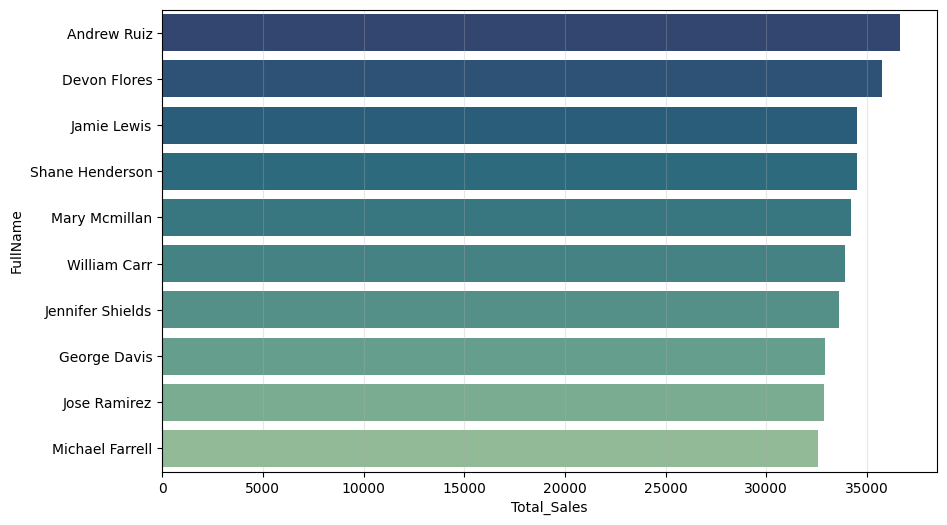

In [11]:
import seaborn as sns
pyp.figure(figsize=(10, 6))
top_10 = df.sort_values(by='Total_Sales', ascending=False).head(10)
sns.barplot(data=top_10, y='FullName', x='Total_Sales', palette='crest_r')
pyp.grid(axis='x', alpha=0.3)
pyp.show()

C:\Users\Omar\AppData\Local\Temp\ipykernel_9260\3364485534.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_sales, x='Department', y='Total_Sales', palette='magma')


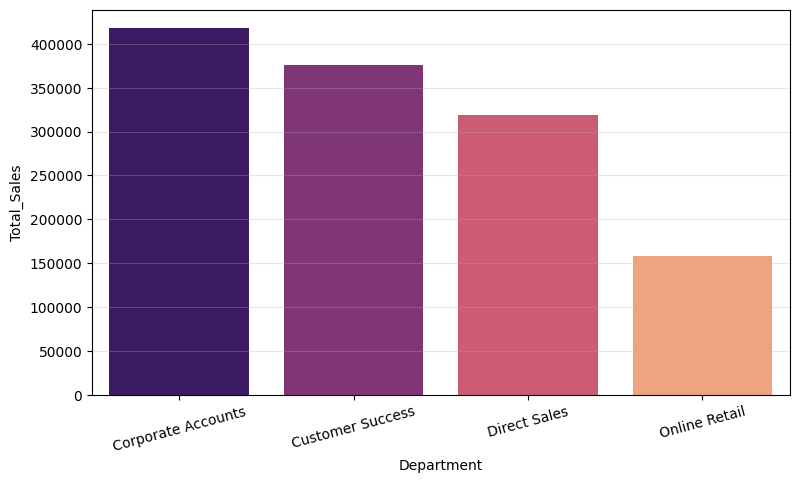

In [13]:

pyp.figure(figsize=(9, 5))
dept_sales = df.groupby('Department')['Total_Sales'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=dept_sales, x='Department', y='Total_Sales', palette='magma')
pyp.xticks(rotation=15)
pyp.grid(axis='y', alpha=0.3)
pyp.show()


In [14]:
df.to_csv('employees_cleaned.csv', index=False)
print("✅ تم حفظ جدول الموظفين النهائي مع المبيعات في 'employees_cleaned.csv' بنجاح!")


✅ تم حفظ جدول الموظفين النهائي مع المبيعات في 'employees_cleaned.csv' بنجاح!
